In [388]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [389]:
import numpy as np

def cxcywh_to_xyxy(cx, cy, w, h):

    xmin = cx- w/2
    ymin = cy - h/2
    xmax = cx + w/2
    ymax = cy + h/2
    return np.array([[xmin, ymin],
                     [xmax, ymin],
                     [xmax, ymax],
                     [xmin, ymax]])  # 4 corners (px)

In [390]:
import random
import numpy as np
from PIL import Image
import torch

class RandomFlip(object):
    def __init__(self, p_horizontal=0.5, p_vertical=0.5):
        self.p_horizontal = p_horizontal
        self.p_vertical = p_vertical

    def _parse_label(self, label):
        lbl = label.clone() if isinstance(label, torch.Tensor) else torch.as_tensor(label, dtype=torch.float32)
        if lbl.numel() == 0:
            return lbl, torch.tensor([], dtype=lbl.dtype)

        # assume last 8 values are 4 corners; if not available, fallback to last 4 (cx,cy,w,h)
        if lbl.numel() >= 8:
            corners = lbl[-8:].clone()
            kps_flat = lbl[:-8].clone()
        elif lbl.numel() >= 4:
            kps_flat = lbl[:-4].clone()
            cx, cy, w, h = [float(x) for x in lbl[-4:].tolist()]
            corners_np = cxcywh_to_xyxy(cx, cy, w, h)
            corners = torch.as_tensor(corners_np.flatten(), dtype=lbl.dtype)
        else:
            kps_flat = lbl.clone()
            corners = torch.tensor([], dtype=lbl.dtype)

        return kps_flat, corners

    def _pack_label(self, kps_flat, corners):
        parts = []
        if kps_flat is not None and kps_flat.numel() > 0:
            parts.append(kps_flat.view(-1))
        if corners is not None and corners.numel() > 0:
            parts.append(corners.view(-1))
        if parts:
            return torch.cat(parts)
        return torch.tensor([], dtype=corners.dtype if corners.numel()>0 else torch.float32)

    def __flipHorizontal(self, image_np, label):    
        if random.random() > self.p_horizontal:
            return image_np, label
        
        flipped_image = np.ascontiguousarray(image_np[:, ::-1])

        if flipped_image.size == 0:
            return image_np, label
        
        kps_flat, corners = self._parse_label(label)

        # flip keypoints x
        if kps_flat.numel() > 0:
            if kps_flat.numel() % 3 == 0:
                kps = kps_flat.view(-1, 3).clone()
            elif kps_flat.numel() % 2 == 0:
                kps2 = kps_flat.view(-1, 2).clone()
                kps = torch.ones((kps2.shape[0], 3), dtype=kps2.dtype)
                kps[:, :2] = kps2
            else:
                n = (kps_flat.numel() // 3) * 3
                kps = kps_flat[:n].view(-1, 3).clone()

            kps[:, 0] = 1.0 - kps[:, 0]
            kps_flat_out = kps.view(-1)
        else:
            kps_flat_out = torch.tensor([], dtype=torch.float32)

        # flip corners (x coordinates)
        if corners.numel() == 8:
            corners_out = corners.clone()
            corners_out[0::2] = 1.0 - corners_out[0::2]
        else:
            corners_out = corners.clone() if corners.numel()>0 else torch.tensor([], dtype=torch.float32)

        flipped_tensor = self._pack_label(kps_flat_out, corners_out)

        return flipped_image, flipped_tensor
    
    def __flipVertical(self, image_np, label):
        if random.random() > self.p_vertical:
            return image_np, label
        
        flipped_image = np.ascontiguousarray(image_np[::-1, :])

        if flipped_image.size == 0:
            return image_np, label
        
        kps_flat, corners = self._parse_label(label)

        # flip keypoints y
        if kps_flat.numel() > 0:
            if kps_flat.numel() % 3 == 0:
                kps = kps_flat.view(-1, 3).clone()
            elif kps_flat.numel() % 2 == 0:
                kps2 = kps_flat.view(-1, 2).clone()
                kps = torch.ones((kps2.shape[0], 3), dtype=kps2.dtype)
                kps[:, :2] = kps2
            else:
                n = (kps_flat.numel() // 3) * 3
                kps = kps_flat[:n].view(-1, 3).clone()

            kps[:, 1] = 1.0 - kps[:, 1]
            kps_flat_out = kps.view(-1)
        else:
            kps_flat_out = torch.tensor([], dtype=torch.float32)

        # flip corners (y coordinates)
        if corners.numel() == 8:
            corners_out = corners.clone()
            corners_out[1::2] = 1.0 - corners_out[1::2]
        else:
            corners_out = corners.clone() if corners.numel()>0 else torch.tensor([], dtype=torch.float32)

        flipped_tensor = self._pack_label(kps_flat_out, corners_out)

        return flipped_image, flipped_tensor
        
    def __call__(self, image, boxes):
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, boxes

        flipped_image, flipped_boxes = self.__flipHorizontal(image_np, boxes)
        flipped_image, flipped_boxes = self.__flipVertical(flipped_image, flipped_boxes)

        image_out = Image.fromarray(flipped_image) if is_pil else flipped_image

        if isinstance(flipped_boxes, torch.Tensor):
            if flipped_boxes.numel() > 0:
                return image_out, flipped_boxes
            return image_out, torch.zeros((0,), dtype=torch.float32)

        if flipped_boxes is not None and len(flipped_boxes) > 0:
            return image_out, torch.as_tensor(flipped_boxes, dtype=torch.float32)

        return image_out, torch.zeros((0,), dtype=torch.float32)


In [391]:
class RandomBoxScale(object):
    def __init__(self, min_scale=0.5, max_scale=2.0, p=0.5):
        self.min_scale = min_scale
        self.max_scale = max_scale
        self.p = p

    def __call__(self, image, boxes):
        if random.random() > self.p:
            return image, boxes
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, boxes

        h, w, _ = image_np.shape
        scale = random.uniform(self.min_scale, self.max_scale)

        scaled_boxes = []
        if boxes is not None and len(boxes) > 0:
            boxes_tensor = boxes.clone() if isinstance(boxes, torch.Tensor) else torch.as_tensor(boxes, dtype=torch.float32)

            for box in boxes_tensor:
                cls, xmin, ymin, xmax, ymax = box.tolist()
                cx = (xmin + xmax) * 0.5
                cy = (ymin + ymax) * 0.5
                bw = (xmax - xmin) * scale
                bh = (ymax - ymin) * scale

                new_xmin = max(0.0, cx - bw * 0.5)
                new_ymin = max(0.0, cy - bh * 0.5)
                new_xmax = min(1.0, cx + bw * 0.5)
                new_ymax = min(1.0, cy + bh * 0.5)

                if new_xmax > new_xmin and new_ymax > new_ymin:
                    scaled_boxes.append([
                        cls,
                        new_xmin,
                        new_ymin,
                        new_xmax,
                        new_ymax,
                    ])

        return image, torch.tensor(scaled_boxes, dtype=torch.float32) if scaled_boxes else boxes

In [392]:
import cv2

class RandomRotate(object):
    def __init__(self, max_angle=30, min_angle=-30, p=0.5):
        self.max_angle = max_angle
        self.min_angle = min_angle
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, label

        h, w, _ = image_np.shape
        angle = random.uniform(self.min_angle, self.max_angle)

        center = (w / 2.0, h / 2.0)
        rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_image = cv2.warpAffine(image_np, rot_matrix, (w, h), flags=cv2.INTER_LINEAR)

        if rotated_image.size == 0:
            return image, label
        
        # make sure label is a tensor
        lbl = label.clone() if isinstance(label, torch.Tensor) else torch.as_tensor(label, dtype=torch.float32)
        if lbl.numel() == 0:
            image_out = Image.fromarray(rotated_image) if is_pil else rotated_image
            return image_out, lbl

        # Expect last 8 values to be 4 corners (x,y) pairs (normalized), but handle other cases too
        if lbl.numel() >= 8:
            corners = lbl[-8:].clone()
            kps_flat = lbl[:-8].clone()
        elif lbl.numel() >= 4:
            # fallback: last 4 are bbox (cx,cy,w,h) -> convert to 4 corners
            kps_flat = lbl[:-4].clone()
            cx, cy, bw, bh = [float(x) for x in lbl[-4:].tolist()]
            corners_np = cxcywh_to_xyxy(cx, cy, bw, bh)  # returns 4x2 in normalized coords
            corners = torch.as_tensor(corners_np.flatten(), dtype=lbl.dtype)
        else:
            # nothing to rotate
            corners = lbl.new_tensor([], dtype=lbl.dtype)
            kps_flat = lbl.clone()

        # rotate keypoints (support x,y or x,y,v formats)
        kps_out = None
        if kps_flat.numel() > 0:
            if kps_flat.numel() % 3 == 0:
                kps = kps_flat.view(-1, 3).clone()
            elif kps_flat.numel() % 2 == 0:
                kps2 = kps_flat.view(-1, 2).clone()
                kps = torch.ones((kps2.shape[0], 3), dtype=kps2.dtype)
                kps[:, 0:2] = kps2
            else:
                n = (kps_flat.numel() // 3) * 3
                kps = kps_flat[:n].view(-1, 3).clone()

            pts_px = np.stack([ (kps[:,0].cpu().numpy() * w), (kps[:,1].cpu().numpy() * h) ], axis=1)
            if pts_px.shape[0] > 0:
                ones = np.ones((pts_px.shape[0], 1))
                pts_h = np.hstack([pts_px, ones])
                rot = (rot_matrix @ pts_h.T).T
                kps[:,0] = torch.from_numpy(rot[:,0] / w).to(kps.dtype)
                kps[:,1] = torch.from_numpy(rot[:,1] / h).to(kps.dtype)
                kps[:,0:2] = kps[:,0:2].clamp(0.0, 1.0)
                kps_out = kps.view(-1)

        # rotate corners if present
        corners_out = None
        if corners.numel() == 8:
            corners_xy = corners.view(4, 2).clone()
            pts_px = np.stack([corners_xy[:,0].cpu().numpy() * w, corners_xy[:,1].cpu().numpy() * h], axis=1)
            ones = np.ones((pts_px.shape[0], 1))
            pts_h = np.hstack([pts_px, ones])
            rot_c = (rot_matrix @ pts_h.T).T
            corners_xy[:,0] = torch.from_numpy(rot_c[:,0] / w).to(corners_xy.dtype)
            corners_xy[:,1] = torch.from_numpy(rot_c[:,1] / h).to(corners_xy.dtype)
            corners_xy = corners_xy.clamp(0.0, 1.0)
            corners_out = corners_xy.view(-1)

        parts = []
        if kps_out is not None:
            parts.append(kps_out)
        if corners_out is not None:
            parts.append(corners_out)

        if parts:
            out_label = torch.cat(parts).to(lbl.dtype)
        else:
            out_label = lbl

        image_out = Image.fromarray(rotated_image) if is_pil else rotated_image
        return image_out, out_label


In [393]:
class RandomGaussianBlur(object):
    def __init__(self, kernel_size=5, p=0.5):
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, label

        blurred_image = cv2.GaussianBlur(image_np, (self.kernel_size, self.kernel_size), 0)

        if blurred_image.size == 0:
            return image, label

        image_out = Image.fromarray(blurred_image) if is_pil else blurred_image
        return image_out, label

In [394]:
class RandomMotionBlur(object):
    def __init__(self, kernel_size=5, p=0.5):
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            print("Image is not 3-channel, skipping motion blur.")
            return image, label

        kernel_motion_blur = np.zeros((self.kernel_size, self.kernel_size))
        kernel_motion_blur[int((self.kernel_size - 1) / 2), :] = np.ones(self.kernel_size)
        kernel_motion_blur /= self.kernel_size

        blurred_image = cv2.filter2D(image_np, -1, kernel_motion_blur)

        if blurred_image.size == 0:
            print("Blurred image is empty, skipping motion blur.")
            return image, label

        image_out = Image.fromarray(blurred_image) if is_pil else blurred_image
        return image_out, label

In [395]:
from pathlib import Path

from torch.utils.data import Dataset


class YoloDataset(Dataset):
    def __init__(self, images_dir: Path, labels_dir: Path, transform=None):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transform = transform

        allowed_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        self.samples = []

        for image_path in self.images_dir.iterdir():
            if image_path.suffix.lower() not in allowed_ext:
                continue

            label_path = self.labels_dir / f"{image_path.stem}.txt"
            if label_path.exists():
                self.samples.append((image_path, label_path))

        if not self.samples:
            raise RuntimeError(f"Nu exista perechi imagine-label in {self.images_dir}")

        self.randomFlip = RandomFlip(p_horizontal=0.5, p_vertical=0.5)
        self.randomRotate = RandomRotate(max_angle=30, min_angle=-30, p=0.5)
        self.randomMotionBlur = RandomMotionBlur(kernel_size=3, p=0.5)
        self.randomGaussianBlur = RandomGaussianBlur(kernel_size=5, p=0.5)
        
    def __len__(self):
        return len(self.samples)
    
    def _read_label(self, label_path: Path):
        with open(label_path, 'r') as f:
            features = f.readline().strip().split(" ")

        cls = int(features[0])
        cx, cy, w, h = [float(point) for point in features[1:5]]
        # keep bbox in center-format (cx, cy, w, h)
        bbox = cxcywh_to_xyxy(cx, cy, w, h).flatten().tolist()

        # read all keypoint values (x, y, visibility) so each keypoint is 3 values
        handKeypoints = [float(point) for point in features[5:]]
        keypointsTensor = torch.tensor(handKeypoints, dtype=torch.float32) if handKeypoints else torch.tensor([], dtype=torch.float32)
        bboxTensor = torch.tensor(bbox, dtype=torch.float32)

        label = torch.cat((keypointsTensor, bboxTensor), dim=0)
        return label
    
    def _cropImage(self, image, label):
        cropPadding = 0.05
        orig_w, orig_h = image.size

        # last 8 values are 4 corner (x,y) pairs: may be normalized [0,1] or absolute pixels
        corners = label[-8:].clone()
        keypoints = label[:-8]

        # normalize corners to [0,1] if they are in pixels
        if corners.max() > 1.0:
            corners_norm = corners.clone()
            corners_norm[0::2] = corners[0::2] / orig_w
            corners_norm[1::2] = corners[1::2] / orig_h
        else:
            corners_norm = corners.clone()

        xs = corners_norm[0::2]
        ys = corners_norm[1::2]
        x_min = float(xs.min()); y_min = float(ys.min())
        x_max = float(xs.max()); y_max = float(ys.max())

        pad = cropPadding
        x_min_px = max(0, int((x_min - pad) * orig_w))
        y_min_px = max(0, int((y_min - pad) * orig_h))
        x_max_px = min(orig_w, int((x_max + pad) * orig_w))
        y_max_px = min(orig_h, int((y_max + pad) * orig_h))

        crop_w = max(1, x_max_px - x_min_px)
        crop_h = max(1, y_max_px - y_min_px)

        croppedImage = image.crop((x_min_px, y_min_px, x_max_px, y_max_px))

        # adjust keypoints to cropped image (normalized)
        if keypoints.numel() > 0:
            kps = keypoints.view(-1, 3).clone()
            # detect if keypoints are in pixels (>1) or normalized (<=1)
            if kps[:, 0].max() > 1.0 or kps[:, 1].max() > 1.0:
                # pixel coords -> make relative to crop and normalize
                kps[:, 0] = (kps[:, 0] - x_min_px) / crop_w
                kps[:, 1] = (kps[:, 1] - y_min_px) / crop_h
            else:
                # normalized coords -> convert to pixels then to cropped normalized
                kps[:, 0] = (kps[:, 0] * orig_w - x_min_px) / crop_w
                kps[:, 1] = (kps[:, 1] * orig_h - y_min_px) / crop_h
            kps[:, 0:2] = kps[:, 0:2].clamp(0.0, 1.0)
            keypoints_flat = kps.view(-1)
        else:
            keypoints_flat = torch.tensor([], dtype=label.dtype)

        # keep corner coordinates normalized relative to cropped image
        corners_crop = corners_norm.clone()
        corners_crop[0::2] = (corners_norm[0::2] * orig_w - x_min_px) / crop_w
        corners_crop[1::2] = (corners_norm[1::2] * orig_h - y_min_px) / crop_h
        corners_crop = corners_crop.clamp(0.0, 1.0)
        # avoid using label.new_tensor on a tensor (causes UserWarning)
        bbox = corners_crop.clone().to(dtype=label.dtype)

        if keypoints_flat.numel() > 0:
            cropped_label = torch.cat((keypoints_flat, bbox), dim=0)
        else:
            cropped_label = bbox

        return croppedImage, cropped_label
    
    def __getitem__(self, idx):
        image_path, label_path = self.samples[idx]

        label = self._read_label(label_path)
        image = Image.open(image_path).convert("RGB")
        
        cropped_image, cropped_label = self._cropImage(image, label)

        if self.transform is not None:
            cropped_image, cropped_label = self.randomMotionBlur(cropped_image, cropped_label)
            cropped_image, cropped_label = self.randomGaussianBlur(cropped_image, cropped_label)
            cropped_image, cropped_label = self.randomFlip(cropped_image, cropped_label)
            cropped_image, cropped_label = self.randomRotate(cropped_image, cropped_label)
            cropped_image = self.transform(cropped_image)

        return cropped_image, cropped_label
    
from torchvision import transforms

image_size = 300

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Face valorile [-2, 2]
])

trainDataset = YoloDataset("dataset/hand-keypoints/images/train",
                        "dataset/hand-keypoints/labels/train", transform=transform)
                        
testDataset = YoloDataset("dataset/hand-keypoints/images/val",
                        "dataset/hand-keypoints/labels/val", transform=transform)

print(f"Numar de imagini pentru antrenare: {len(trainDataset)}")
print(f"Numar de imagini pentru testare: {len(testDataset)}")

print(f"shape label: {trainDataset[0][1].shape}")

Numar de imagini pentru antrenare: 18776
Numar de imagini pentru testare: 7992
shape label: torch.Size([71])


bbox corners: [[69.50482177734375, 5.05379581451416], [287.3773498535156, 98.58934020996094], [232.3798370361328, 299.7694396972656], [14.507308959960938, 206.23388671875]]


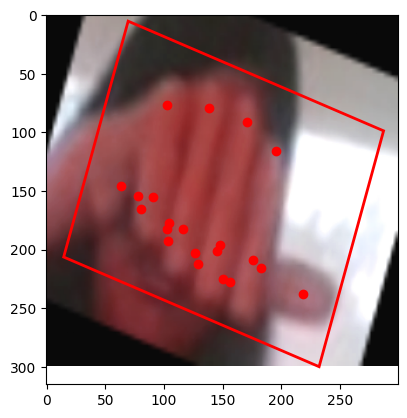

In [409]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

randomIndex = random.randint(0, len(testDataset) - 1)
img_tensor, label_tensor = testDataset[randomIndex]
# print(label_tensor)

img = img_tensor.permute(1, 2, 0).numpy() 

fig, ax = plt.subplots(1)
ax.imshow(img)

h, w, _ = img.shape

for keypoint in range(0, len(label_tensor) - 8, 3):
    x, y = label_tensor[keypoint], label_tensor[keypoint + 1]
    # print(f"keypoint {keypoint//3}: ({x * w:.2f}, {y * h:.2f})" )
    ax.plot(x * w, y * h, 'ro')

bbox = label_tensor[-8:].view(4, 2).clone()
bbox[:, 0] *= w
bbox[:, 1] *= h

poly = patches.Polygon(
    bbox.detach().cpu().numpy(),
    closed=True,
    linewidth=2,
    edgecolor='r',
    facecolor='none'
)
print(f"bbox corners: {bbox.tolist()}")
ax.add_patch(poly)


plt.show()